In [7]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load mnist dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

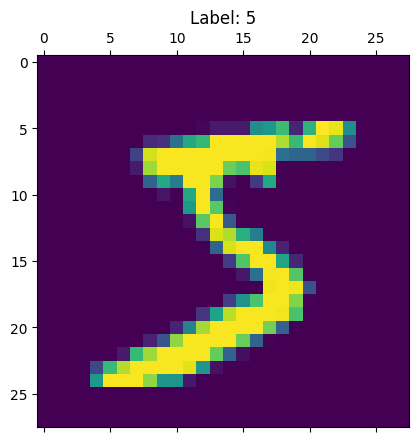

In [8]:
# Visualise first image
plt.matshow(X_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()

In [9]:
# Normalise pixel values from range [0,255] → [0,1] so we could improve descent performance and convergence
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for cnn
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [10]:
# baseline ann
# flatten image then dense layers

ann_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
ann_model.fit(X_train.reshape(-1,28,28), y_train, epochs=10)

# Evaluate
ann_model.evaluate(X_test.reshape(-1,28,28), y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 441us/step - accuracy: 0.9211 - loss: 0.2770
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 391us/step - accuracy: 0.9625 - loss: 0.1270
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 376us/step - accuracy: 0.9728 - loss: 0.0900
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 371us/step - accuracy: 0.9791 - loss: 0.0683
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 387us/step - accuracy: 0.9837 - loss: 0.0533
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 384us/step - accuracy: 0.9860 - loss: 0.0433
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 379us/step - accuracy: 0.9901 - loss: 0.0343
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 390us/step - accuracy: 0.9906 - loss: 0.0296
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 383us/step - accuracy: 0.9923 - loss: 0.0243
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 387us/step - accuracy: 0.9938 - loss: 0.0203
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - accuracy: 0.9801 - loss: 0.0776


[0.07756815105676651, 0.9800999760627747]

In [13]:
# cnn
# Uses convolution to detect edges, curves

cnn_model = keras.Sequential([
    layers.Conv2D(30, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
cnn_model.fit(X_train, y_train, epochs=5)

# Evaluate performance
cnn_model.evaluate(X_test, y_test)
#Results I have achieved:
#cnn showed much higher accuracy: 99%


#Analysis:
# cnn clearly outperforms ann due to convolution layers better extracting  features and nn requires fewer epochs to reach higher accuracy.

#Conclusion:
#The cnn model demonstrates better performance for image classification tasks.


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9539 - loss: 0.1536
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9831 - loss: 0.0545
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0354
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9920 - loss: 0.0251
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9945 - loss: 0.0166
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.9865 - loss: 0.0455


[0.04551397264003754, 0.9865000247955322]